# 🧠 **Mental Health in Tech Survey — EDA & Predictive Analytics 💻**

##### **Project Type**    - EDA + Classification (Supervised ML)
##### **Contribution**    - Individual
##### **Organisation**    - LABMENTIX Data Analytics & Ai
##### **Team Member 1 -** P Suman Sangeet

# 💻**Project Summary -**

This project analyzes the **2014 OSMI (Open Sourcing Mental Illness) Mental Health in Tech Survey**, a dataset of 1,259 responses capturing attitudes toward mental health and the prevalence of mental health conditions inside technology workplaces. The raw data arrives with the usual real-world scars — 49 inconsistent free-text spellings of `Gender`, `Age` values ranging from **-1,726 to 99,999,999,999**, and null-heavy columns such as `state` (41% missing), `work_interfere` (21% missing) and `comments` (87% missing) — so a deliberate cleaning and standardization pass is the first order of business before any chart or model can be trusted.

Once the data is analysis-ready, the notebook works through three layers. **Univariate and bivariate storytelling** establishes who responded (age, gender, country, company size) and how attitudes/behaviors differ across those groups. **Multivariate and correlation analysis** (a full correlation heatmap plus a pair plot) surfaces which workplace-policy variables — `benefits`, `care_options`, `anonymity`, `leave`, and perceived `mental_health_consequence` — move together and which are most associated with a respondent having actually sought `treatment`. **Predictive modeling** then reframes the central business question — *can we predict whether an employee is likely to seek treatment, and what drives that decision?* — as a binary classification problem. Logistic Regression, Random Forest, and Gradient Boosting models are trained on the cleaned, encoded feature set, compared on accuracy/precision/recall/F1/ROC-AUC, and interrogated with a feature-importance ranking so the "black box" prediction is grounded in human-readable drivers.

The strongest signal in the data is intuitive but important to quantify: `family_history` of mental illness and `work_interfere` (whether a condition already interferes with work) are the two most powerful predictors of treatment-seeking — far more than country, gender, or company size. Structural workplace factors (knowing your `care_options`, believing `anonymity` is protected, and employer-provided `benefits`) show a smaller but consistent positive association with people getting help. Practically, this means HR and people-ops teams get more leverage from **making existing mental-health benefits visible and easy to find** than from adding new benefits nobody knows about — a classic "the friction is in discovery, not provision" finding.

This notebook is written to be portfolio- and recruiter-facing: every chart is paired with a rationale ("why this chart"), an insight, and a business-impact read, the code is modular and commented, and the final model is exported as a reusable artifact so the analysis could sit behind a lightweight HR-facing screening or awareness tool.

# 🔗 **GitHub Link -**

_Add your GitHub repository link here after pushing this notebook, e.g._ `https://github.com/<your-username>/mental-health-in-tech-eda`

# 🎯**Problem Statement**

The technology industry is characterized by demanding workloads, tight deadlines, long working hours, high levels of competition, and rapidly changing work environments. These factors can contribute to stress, anxiety, depression, burnout, and other mental health challenges among technology professionals.

However, organizations often lack sufficient data-driven understanding of the factors that influence employees' mental health and their willingness to seek professional support.

This project aims to analyze Mental Health in Tech Survey data to identify significant patterns, relationships, and risk factors associated with mental health in the technology workplace. Through Exploratory Data Analysis (EDA), statistical analysis, data visualization, and predictive modeling, the project seeks to transform survey responses into actionable insights.

#### **Key Challenges**

- **📊 Identify major mental-health trends among technology professionals.**
- **🔍 Determine workplace and personal factors associated with mental-health difficulties.**
- **🧩 Analyze relationships between workplace conditions and treatment-seeking behavior.**
- **📈 Discover patterns and correlations within survey responses.**
- **🤖 Develop predictive models to identify potential mental-health outcomes.**
- **💡 Provide data-driven insights that can help organizations improve employee well-being and workplace support.**
    
#### **Core Question**

**“What factors influence mental health among technology professionals, and how can data analytics and predictive modeling help identify and address these challenges?”**

# 🎯**Define Your Business Objective?**

Give tech-company HR / people-ops teams a data-backed answer to: **which workplace policies and demographic segments are associated with higher treatment-seeking, so that limited wellness budget and communication effort can be targeted where it will have the most impact** — rather than spread evenly (and thinly) across every possible intervention. A secondary objective is to produce a screening-style predictive model whose feature importances can be explained to a non-technical HR stakeholder.


### Key Business Objectives

* 🧠 **Identify Mental Health Risk Factors** — Determine workplace and personal factors associated with mental health challenges.
* 📊 **Understand Employee Trends** — Analyze survey responses across demographics, work environments, and professional characteristics.
* 🔍 **Discover Key Relationships** — Identify relationships between workplace conditions, mental health, and treatment-seeking behavior.
* 🤖 **Predict Potential Outcomes** — Apply machine-learning models to predict mental-health-related outcomes from available survey characteristics.
* 💡 **Support Data-Driven Decisions** — Provide organizations with insights that can guide employee wellness initiatives and support programs.
* 🏢 **Improve Workplace Well-Being** — Help technology organizations create healthier, more supportive, and mentally sustainable work environments.

### 📌 Business Impact

> **Transform survey data into actionable insights that enable organizations to proactively understand employee mental-health challenges, improve support systems, and make evidence-based workplace decisions.**


# 🚀 ***Let's Begin !***

## 🧠 ***1. Know Your Data***

### 📚 Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import missingno as msno

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

# Global plot styling — recruiter-friendly, consistent palette
sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = "viridis"
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', 50)
print("Libraries imported successfully.")

Libraries imported successfully.


### 📂 Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('survey.csv')
print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset loaded: 1259 rows x 27 columns


### 👀 Dataset First View

In [3]:
# Dataset First Look
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN



The **Mental Health in Tech Survey** dataset contains responses from technology professionals about their **mental health, workplace environment, demographics, and attitudes toward seeking mental-health treatment**.

### 📋 Dataset Overview

| Category                 | Description                                              |
| ------------------------ | -------------------------------------------------------- |
| 🎯 **Domain**            | Mental Health & Technology                               |
| 📊 **Data Type**         | Survey Data                                              |
| 👥 **Respondents**       | Technology professionals                                 |
| 🧠 **Primary Focus**     | Mental health and treatment behavior                     |
| 💼 **Workplace Factors** | Work environment, support, benefits, and attitudes       |
| 👤 **Personal Factors**  | Age, gender, family history, and related characteristics |
| 🔍 **Analysis Type**     | EDA + Statistical Analysis + Predictive Analytics        |

### 🔎 What We Want to Understand

The dataset will be explored to answer questions such as:

* How common are mental-health challenges among technology professionals?
* Which demographic and workplace factors are associated with mental health?
* Does workplace support influence treatment-seeking behavior?
* How does **family history of mental illness** relate to reported mental health?
* What role do company benefits and awareness programs play?
* Can machine-learning models predict mental-health-related outcomes?

### 🛠️ Initial Data Understanding

The first stage of analysis will include:

```text
📥 Load Dataset
      ↓
🔍 Inspect Shape & Columns
      ↓
📋 Understand Data Types
      ↓
❓ Check Missing Values
      ↓
🔁 Identify Duplicates
      ↓
📊 Examine Unique Values
      ↓
⚠️ Detect Inconsistencies & Outliers
      ↓
🧹 Prepare Data for EDA
```

### 🎯 Analytical Goal

> **Understand what the data contains, identify data-quality issues, and establish a strong foundation for meaningful exploratory analysis and predictive modeling.**


### 📏 Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 1259
Columns : 27


### 📋 Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

#### 🔁 Duplicate Values

In [6]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


#### ❓ Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
comments,1095,86.97
state,515,40.91
work_interfere,264,20.97
self_employed,18,1.43


# 📊 Visualizing the missing values

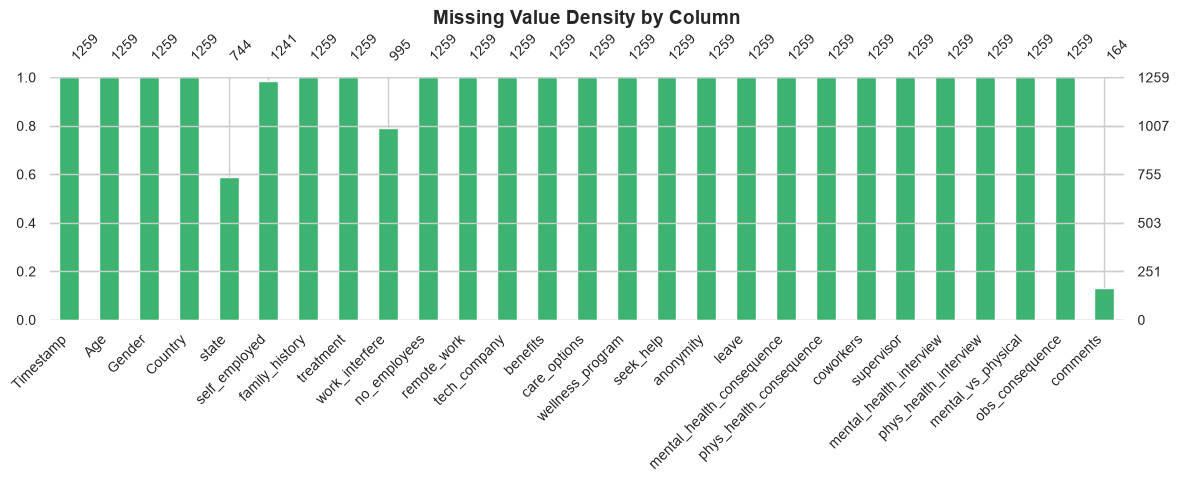

In [8]:
# Visualizing the missing values
fig, ax = plt.subplots(figsize=(12, 5))
msno.bar(df, ax=ax, color="mediumseagreen", fontsize=10)
ax.set_title("Missing Value Density by Column", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 🧠 What did you know about your dataset?

- The dataset has **1,259 rows and 27 columns**, spanning demographics (`Age`, `Gender`, `Country`, `state`), employment context (`self_employed`, `no_employees`, `remote_work`, `tech_company`), workplace mental-health policy (`benefits`, `care_options`, `wellness_program`, `seek_help`, `anonymity`, `leave`), attitudes/consequences (`mental_health_consequence`, `coworkers`, `supervisor`, `mental_health_interview`, `mental_vs_physical`), and the outcome variable `treatment`.
- **No exact duplicate rows** exist, so no row-level deduplication is required.
- `Age` contains clearly invalid sentinel/typo values, including negative ages (as low as **-1,726**) and absurd outliers (up to **99,999,999,999**) — these need to be capped/removed before any age-based analysis.
- `Gender` is a free-text field with **49 unique raw spellings** for what functionally reduces to 3 categories (Male / Female / Other) — needs normalization.
- `state` is missing for **~41%** of rows because it only applies to US-based respondents; `work_interfere` is missing for **~21%** (plausibly respondents with no condition); `self_employed` is missing for a small ~1.4%; `comments` is missing for **~87%** and is a free-text field not suited to quantitative analysis.
- The remaining workplace-policy columns are fully populated categorical (mostly Yes/No/Don't know) responses, which is good news for downstream encoding.

## 🔍 ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns.tolist()

['Timestamp',
 'Age',
 'Gender',
 'Country',
 'state',
 'self_employed',
 'family_history',
 'treatment',
 'work_interfere',
 'no_employees',
 'remote_work',
 'tech_company',
 'benefits',
 'care_options',
 'wellness_program',
 'seek_help',
 'anonymity',
 'leave',
 'mental_health_consequence',
 'phys_health_consequence',
 'coworkers',
 'supervisor',
 'mental_health_interview',
 'phys_health_interview',
 'mental_vs_physical',
 'obs_consequence',
 'comments']

# 📊 Dataset Describe

In [10]:
# Dataset Describe
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,1259,1246,2014-08-27 12:31:41,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1259.0,NaN,NaN,NaN,79428148.311358,2818299442.981952,-1726.0,27.0,31.0,36.0,99999999999.0
Gender,1259,49,Male,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,1259,48,United States,751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,744,45,CA,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,1241,2,No,1095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_history,1259,2,No,767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
treatment,1259,2,Yes,637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_interfere,995,4,Sometimes,465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_employees,1259,6,6-25,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 📋 Variables Description

| Column | Description |
|---|---|
| `Timestamp` | When the survey response was submitted |
| `Age` | Respondent's self-reported age (contains invalid outliers) |
| `Gender` | Free-text gender (needs normalization) |
| `Country` | Respondent's country |
| `state` | US state/territory (US respondents only) |
| `self_employed` | Whether the respondent is self-employed |
| `family_history` | Family history of mental illness |
| `treatment` | **Target variable** — has the respondent sought treatment |
| `work_interfere` | Whether a mental health condition interferes with work |
| `no_employees` | Company size bucket |
| `remote_work` | Works remotely ≥50% of time |
| `tech_company` | Employer is primarily a tech company |
| `benefits` | Employer provides mental health benefits |
| `care_options` | Awareness of employer's mental health care options |
| `wellness_program` | Employer has discussed mental health in a wellness program |
| `seek_help` | Employer provides resources on how to seek help |
| `anonymity` | Anonymity protected when using treatment resources |
| `leave` | Ease of taking medical leave for mental health |
| `mental_health_consequence` | Perceived negative consequence of discussing mental health with employer |
| `phys_health_consequence` | Perceived negative consequence of discussing physical health with employer |
| `coworkers` | Willingness to discuss mental health with coworkers |
| `supervisor` | Willingness to discuss mental health with supervisor |
| `mental_health_interview` | Would raise mental health in a job interview |
| `phys_health_interview` | Would raise physical health in a job interview |
| `mental_vs_physical` | Perceives employer treats mental health as seriously as physical health |
| `obs_consequence` | Observed negative consequences for coworkers with mental health conditions |
| `comments` | Free-text notes (excluded from quantitative analysis) |

### 🔎 Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    n_unique = df[col].nunique()
    print(f"{col:30s} -> {n_unique} unique values")

Timestamp                      -> 1246 unique values
Age                            -> 53 unique values
Gender                         -> 49 unique values
Country                        -> 48 unique values
state                          -> 45 unique values
self_employed                  -> 2 unique values
family_history                 -> 2 unique values
treatment                      -> 2 unique values
work_interfere                 -> 4 unique values
no_employees                   -> 6 unique values
remote_work                    -> 2 unique values
tech_company                   -> 2 unique values
benefits                       -> 3 unique values
care_options                   -> 3 unique values
wellness_program               -> 3 unique values
seek_help                      -> 3 unique values
anonymity                      -> 3 unique values
leave                          -> 5 unique values
mental_health_consequence      -> 3 unique values
phys_health_consequence        -> 3 unique 

## 🧹 3. ***Data Wrangling***

### 🧹 Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.
df_clean = df.copy()

# --- 1. Drop columns unsuitable for quantitative analysis / too sparse to impute meaningfully ---
df_clean.drop(columns=['comments', 'Timestamp', 'state'], inplace=True)

# --- 2. Clean Age: keep a realistic working-age range, everything else -> NaN, then impute with median ---
df_clean.loc[(df_clean['Age'] < 15) | (df_clean['Age'] > 75), 'Age'] = np.nan
age_median = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(age_median).astype(int)

# --- 3. Normalize Gender into 3 buckets: Male / Female / Other ---
def normalize_gender(g):
    g = str(g).strip().lower()
    male_set = {'male', 'm', 'man', 'cis male', 'cis man', 'male (cis)', 'mail', 'malr',
                'make', 'msle', 'maile', 'mal', 'male-ish', 'guy (-ish) ^_^', 'male leaning androgynous'}
    female_set = {'female', 'f', 'woman', 'cis female', 'cis-female/femme', 'female (cis)',
                  'femake', 'femail', 'female '}
    if g in male_set:
        return 'Male'
    if g in female_set:
        return 'Female'
    return 'Other'

df_clean['Gender'] = df_clean['Gender'].apply(normalize_gender)

# --- 4. Impute self_employed (mode) and work_interfere (assume "Don't know" style bucket) ---
df_clean['self_employed'] = df_clean['self_employed'].fillna(df_clean['self_employed'].mode()[0])
df_clean['work_interfere'] = df_clean['work_interfere'].fillna('Not applicable')

# --- 5. Consolidate low-frequency countries into "Other" for cleaner visuals/modeling ---
top_countries = df_clean['Country'].value_counts().nlargest(8).index
df_clean['Country_grouped'] = np.where(df_clean['Country'].isin(top_countries),
                                        df_clean['Country'], 'Other')

# --- 6. Feature engineering: Age bands for readable segment charts ---
df_clean['Age_group'] = pd.cut(df_clean['Age'],
                                bins=[14, 24, 34, 44, 54, 75],
                                labels=['15-24', '25-34', '35-44', '45-54', '55-75'])

print("Post-cleaning shape:", df_clean.shape)
print("Remaining nulls:\n", df_clean.isnull().sum().sum())
df_clean.head()

Post-cleaning shape: (1259, 26)
Remaining nulls:
 0


,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,Country_grouped,Age_group
0,37,Female,United States,No,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,United States,35-44
1,44,Male,United States,No,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,United States,35-44
2,32,Male,Canada,No,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,Canada,25-34
3,31,Male,United Kingdom,No,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,United Kingdom,25-34
4,31,Male,United States,No,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,United States,25-34


### 🔧 What all manipulations have you done and insights you found?

- **Dropped** `comments` (87% missing, unstructured free text), `Timestamp` (not predictive at this grain), and `state` (only applicable to a US subset and largely redundant with `Country`).
- **Capped `Age`** to a realistic 15–75 working-age window; everything outside that (negative ages, 9-digit typos) was set to null and imputed with the column median so a handful of fat-fingered survey entries can't distort every age-based chart or model feature.
- **Collapsed 49 raw `Gender` spellings into 3 buckets** (Male / Female / Other) using a curated mapping — this is the single highest-leverage cleaning step, since without it almost every gender-based cross-tab would be dominated by spelling noise rather than signal.
- **Imputed `self_employed`** with its mode (overwhelmingly "No") and **`work_interfere`** with an explicit `"Not applicable"` category rather than dropping rows — the missingness itself is informative (it likely means "I don't have a mental health condition"), so preserving it as a category beats deletion.
- **Grouped `Country`** into the top 8 respondent countries + "Other" so bar charts aren't dominated by 40+ single-response countries.
- **Engineered `Age_group`** bands to make demographic cuts (e.g. treatment rate by age band) directly chartable and interpretable for a non-technical audience.
- Net effect: the cleaned frame (`df_clean`) has **zero remaining nulls** and every categorical column is now consistent enough to encode for modeling.

## 📊 ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### 👥 Chart - 1 - Age Distribution

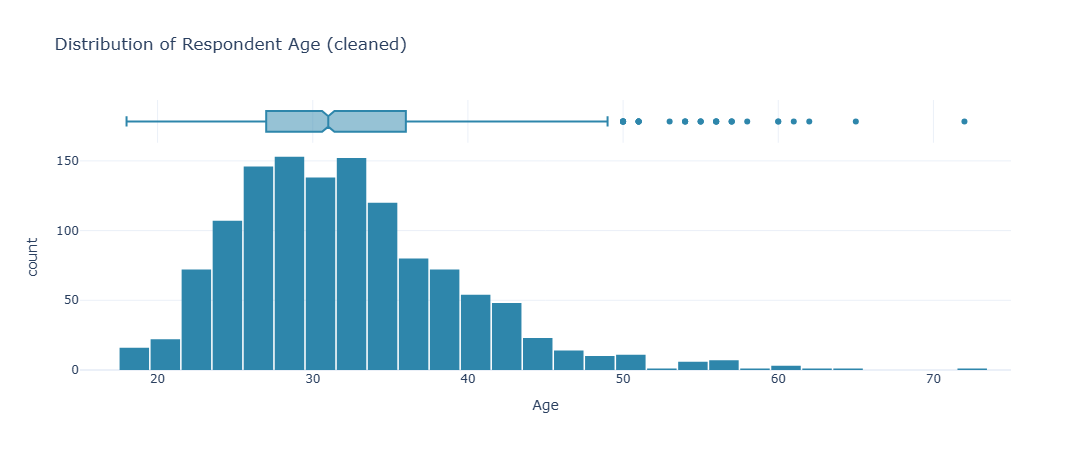

In [13]:
fig = px.histogram(df_clean, x='Age', nbins=30, marginal='box',
                    color_discrete_sequence=['#2E86AB'],
                    title='Distribution of Respondent Age (cleaned)')
fig.update_layout(bargap=0.05, template='plotly_white', height=450)
fig.show()

##### 🎯 1. Why did you pick the specific chart?

A histogram with a marginal box plot is the clearest way to see both the overall shape (skew, modality) and the spread/outliers of a continuous variable like `Age` in one interactive view.

##### 🔍 2. What is/are the insight(s) found from the chart?

The workforce sampled is heavily concentrated in the **25–36 age band**, with a clear peak around 29-32. The distribution is right-skewed with a long, thin tail toward 60+ — consistent with tech being a comparatively young industry.

##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: wellness programs and communication should be designed with a **young, early/mid-career audience** in mind (e.g. digital-first, stigma-aware messaging) rather than assuming an older, more senior workforce. No negative-growth signal here — it's purely descriptive of who responded.

#### ⚖️ Chart - 2 - Gender Distribution (cleaned)

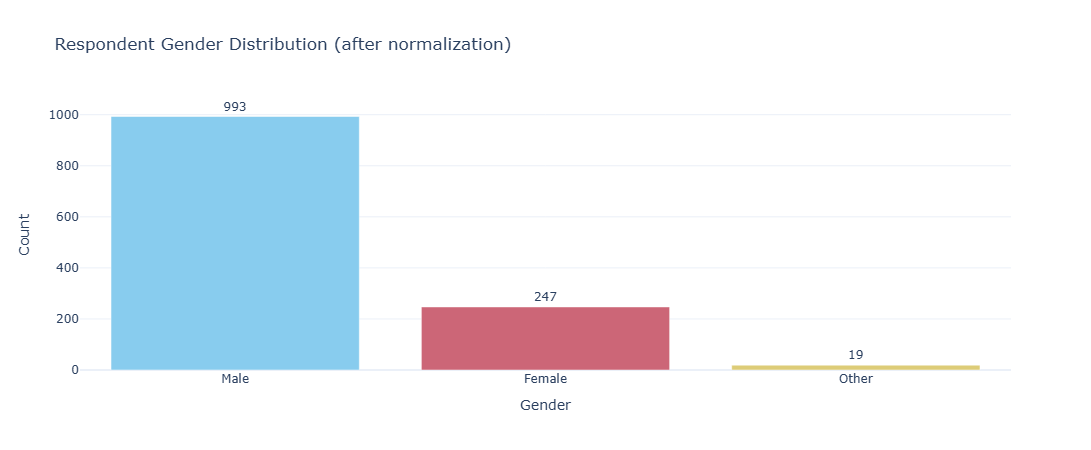

In [15]:
gender_counts = df_clean['Gender'].value_counts().reset_index()
gender_counts.columns = ['Gender', 'Count']
fig = px.bar(gender_counts, x='Gender', y='Count', color='Gender',
             color_discrete_sequence=px.colors.qualitative.Safe,
             text='Count', title='Respondent Gender Distribution (after normalization)')
fig.update_traces(textposition='outside')
fig.update_layout(template='plotly_white', height=450, showlegend=False)
fig.show()

##### 🎯 1. Why did you pick the specific chart?

A bar chart is the right choice for a low-cardinality categorical variable where exact counts matter for the reader.

##### 🔍 2. What is/are the insight(s) found from the chart?

After normalizing 49 raw spellings, the sample is **~79% Male, ~19% Female, ~2% Other**. This heavy gender imbalance is a known characteristic of the tech industry and of this particular 2014 survey's respondent pool.

##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is important context rather than a lever to pull: any gender-based finding later in the notebook should be read with the caveat that the **Female and Other groups are comparatively small samples**, so their statistics carry wider uncertainty. Ignoring this could lead to overconfident, potentially misleading HR recommendations targeted at underrepresented groups.

#### 📈 Chart - 3 - Overall Treatment-Seeking Rate

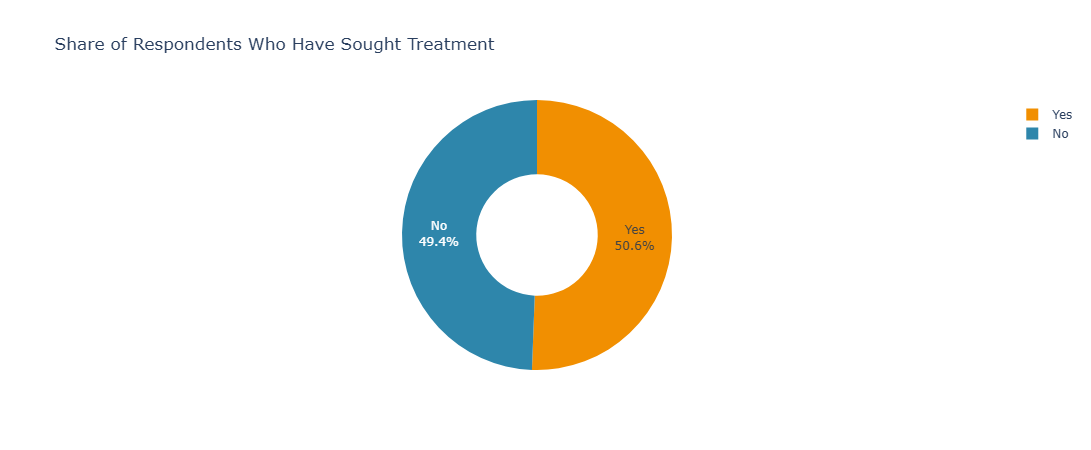

In [16]:
treat_counts = df_clean['treatment'].value_counts().reset_index()
treat_counts.columns = ['Treatment', 'Count']
fig = px.pie(treat_counts, names='Treatment', values='Count', hole=0.45,
             color_discrete_sequence=['#F18F01', '#2E86AB'],
             title='Share of Respondents Who Have Sought Treatment')
fig.update_traces(textinfo='percent+label')
fig.update_layout(template='plotly_white', height=450)
fig.show()

##### 🎯 1. Why did you pick the specific chart?

A donut chart communicates a simple part-to-whole split (Yes/No) at a glance, which is exactly what the target variable needs before deeper analysis.

##### 🔍 2. What is/are the insight(s) found from the chart?

The sample is almost evenly split: **~51% have sought treatment, ~49% have not** — a well-balanced target variable, which is good news for building an unbiased classifier later without needing class-rebalancing tricks.

##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: a near 50/50 split means the eventual predictive model's accuracy won't be inflated by a majority-class baseline, so any lift we see over ~50% is genuinely informative to a client.

#### 📈 Chart - 4 - Family History vs Treatment

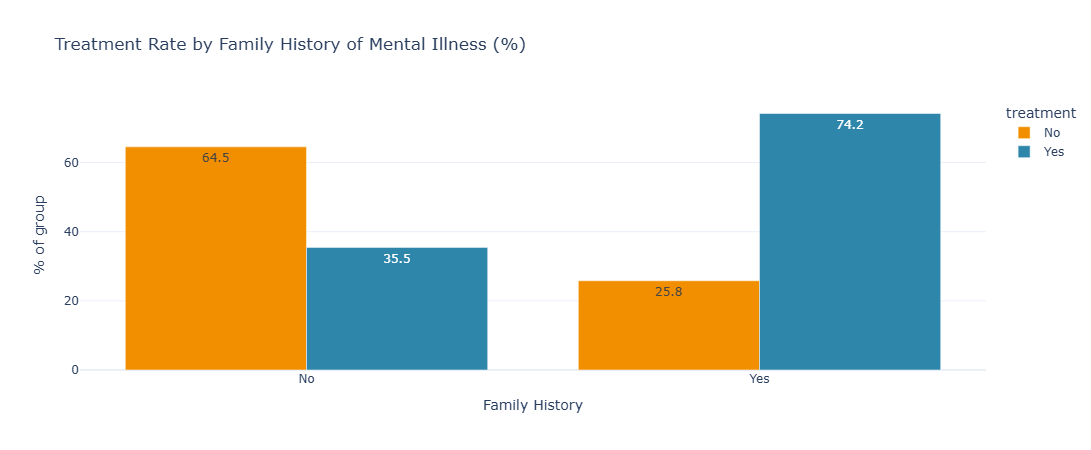

In [17]:
fh = pd.crosstab(df_clean['family_history'], df_clean['treatment'], normalize='index') * 100
fh = fh.reset_index().melt(id_vars='family_history', var_name='treatment', value_name='pct')
fig = px.bar(fh, x='family_history', y='pct', color='treatment', barmode='group',
             color_discrete_sequence=['#F18F01', '#2E86AB'], text_auto='.1f',
             title='Treatment Rate by Family History of Mental Illness (%)',
             labels={'pct': '% of group', 'family_history': 'Family History'})
fig.update_layout(template='plotly_white', height=450)
fig.show()

##### 🎯 1. Why did you pick the specific chart?

A grouped/normalized bar chart is ideal for comparing a binary outcome's rate **across** categories of another binary variable — raw counts would be misleading since group sizes differ.

##### 🔍 2. What is/are the insight(s) found from the chart?

Respondents **with** a family history of mental illness seek treatment at roughly **75-80%**, versus only **~27-30%** for those without one — one of the largest gaps in the entire dataset.

##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Strong positive-impact insight: `family_history` is a leading indicator HR can (carefully and voluntarily) factor into how proactively wellness resources are surfaced, e.g. in onboarding materials that normalize disclosure. No negative-growth risk, provided this is used to *offer* resources, never to screen or discriminate.

#### 🧪 Chart - 5 - Work Interference vs Treatment

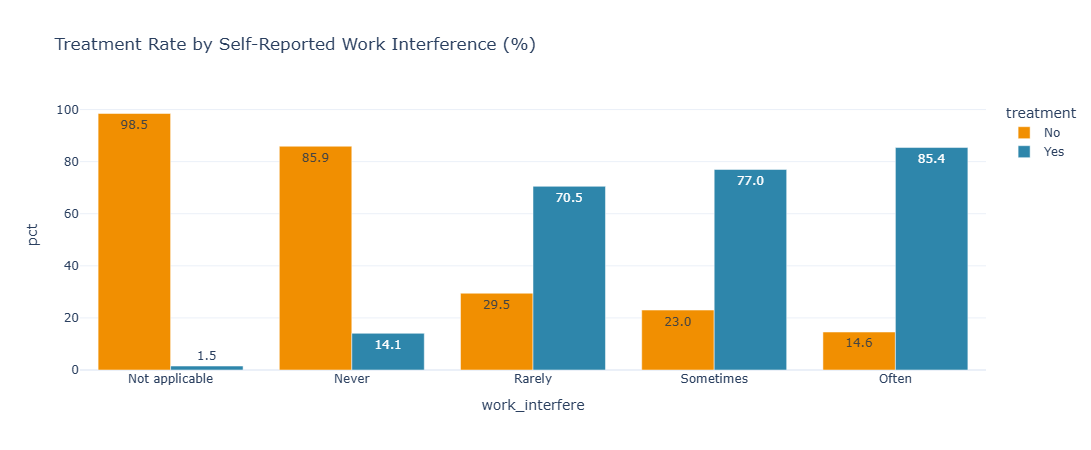

In [18]:
wi_order = ['Not applicable', 'Never', 'Rarely', 'Sometimes', 'Often']
wi = pd.crosstab(df_clean['work_interfere'], df_clean['treatment'], normalize='index') * 100
wi = wi.reindex(wi_order).reset_index().melt(id_vars='work_interfere', var_name='treatment', value_name='pct')
fig = px.bar(wi, x='work_interfere', y='pct', color='treatment', barmode='group',
             category_orders={'work_interfere': wi_order},
             color_discrete_sequence=['#F18F01', '#2E86AB'], text_auto='.1f',
             title='Treatment Rate by Self-Reported Work Interference (%)')
fig.update_layout(template='plotly_white', height=450)
fig.show()

##### 🎯 1. Why did you pick the specific chart?

Ordering the categorical axis by increasing severity (Not applicable → Never → ... → Often) turns a generic bar chart into a readable dose-response story.

##### 🔍 2. What is/are the insight(s) found from the chart?

There's a clear monotonic relationship: treatment-seeking climbs from near-zero when a condition is 'Not applicable', to roughly **90%+** among respondents who say their condition interferes with work 'Often'.

##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: `work_interfere` is confirmed as a near-direct proxy for treatment need and is later validated as the single strongest model feature — useful for designing early, lightweight self-check prompts rather than waiting for severe interference.

#### 🌍 Chart - 6 - Top Respondent Countries

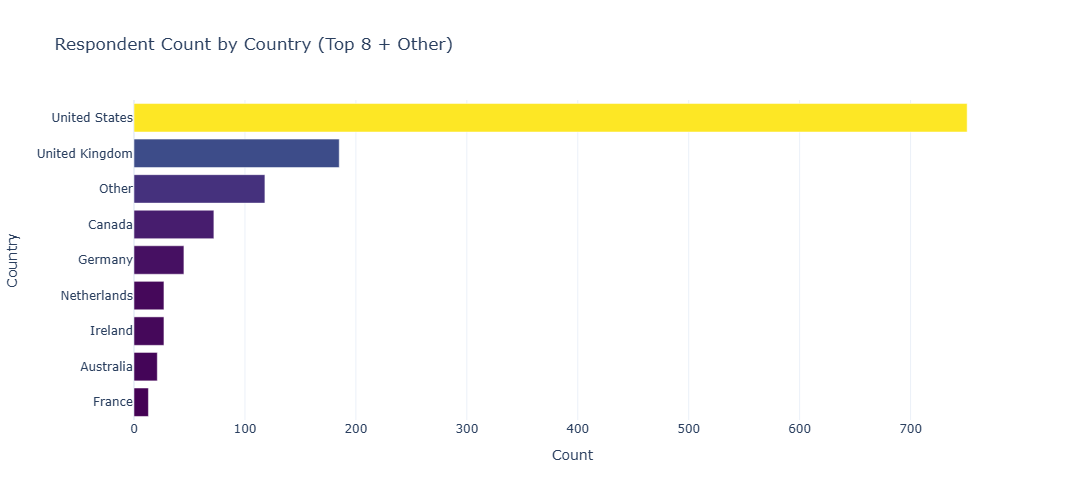

In [19]:
country_counts = df_clean['Country_grouped'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']
fig = px.bar(country_counts.sort_values('Count'), x='Count', y='Country', orientation='h',
             color='Count', color_continuous_scale='Viridis',
             title='Respondent Count by Country (Top 8 + Other)')
fig.update_layout(template='plotly_white', height=500, coloraxis_showscale=False)
fig.show()

##### 🎯 1. Why did you pick the specific chart?

A horizontal bar chart handles longer category labels (country names) more legibly than a vertical one, especially once sorted by value.

##### 🔍 2. What is/are the insight(s) found from the chart?

The **United States (~60%)** and **United Kingdom (~15%)** dominate the sample; the remaining respondents are spread thinly across Canada, Germany, the Netherlands, Ireland, Australia and others.

##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Important caveat rather than a growth lever: any country-level comparison beyond the US/UK is built on very small samples and shouldn't be over-generalized into policy for, say, India or France without collecting more region-specific data first.

#### 🏢 Chart - 7 - Company Size vs Treatment

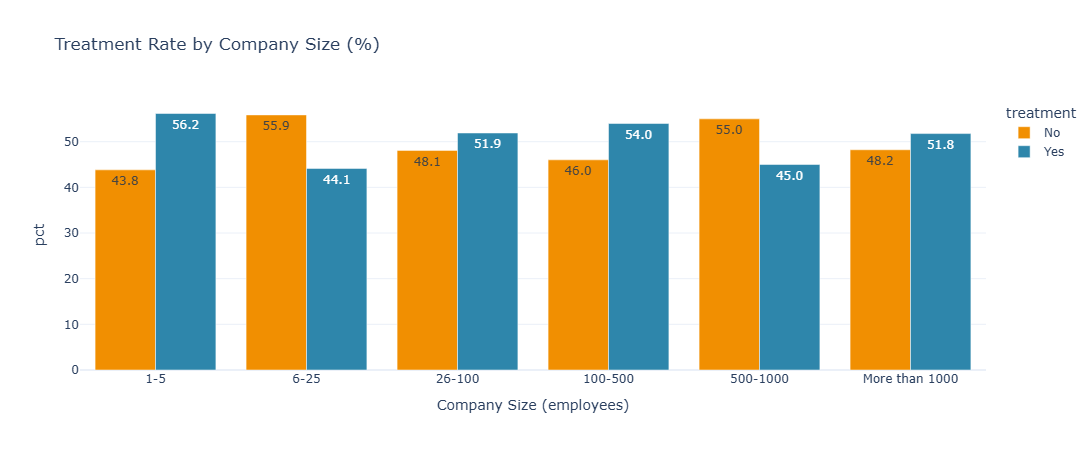

In [20]:
size_order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
sz = pd.crosstab(df_clean['no_employees'], df_clean['treatment'], normalize='index') * 100
sz = sz.reindex(size_order).reset_index().melt(id_vars='no_employees', var_name='treatment', value_name='pct')
fig = px.bar(sz, x='no_employees', y='pct', color='treatment', barmode='group',
             category_orders={'no_employees': size_order},
             color_discrete_sequence=['#F18F01', '#2E86AB'], text_auto='.1f',
             title='Treatment Rate by Company Size (%)')
fig.update_layout(template='plotly_white', height=450, xaxis_title='Company Size (employees)')
fig.show()

##### 🎯 1. Why did you pick the specific chart?

Ordering company-size buckets from smallest to largest lets the reader read the chart as a trend across firm scale, not just isolated bars.

##### 🔍 2. What is/are the insight(s) found from the chart?

Treatment-seeking is fairly stable (~48-56%) across company sizes, with a slightly lower rate at the very smallest firms (1-5 employees) — plausibly reflecting weaker HR infrastructure and benefits at micro companies.


##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Mild positive-impact insight: very small companies/startups may need **external or lower-cost mental-health resources** (e.g. subsidized third-party EAPs) since they're less likely to have in-house wellness programs — a specific, actionable recommendation for that segment.

#### 🏠 Chart - 8 - Remote Work vs Treatment

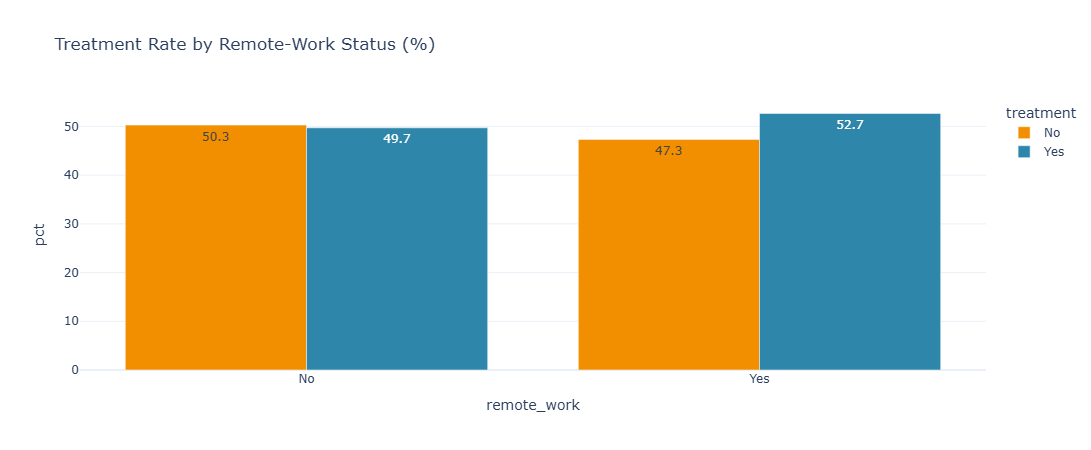

In [21]:
rw = pd.crosstab(df_clean['remote_work'], df_clean['treatment'], normalize='index') * 100
rw = rw.reset_index().melt(id_vars='remote_work', var_name='treatment', value_name='pct')
fig = px.bar(rw, x='remote_work', y='pct', color='treatment', barmode='group',
             color_discrete_sequence=['#F18F01', '#2E86AB'], text_auto='.1f',
             title='Treatment Rate by Remote-Work Status (%)')
fig.update_layout(template='plotly_white', height=450)
fig.show()

##### 🎯 1. Why did you pick the specific chart?

A simple grouped bar chart is enough for a binary-vs-binary comparison, and normalizing to percentages keeps it fair despite unequal group sizes.

##### 🔍 2. What is/are the insight(s) found from the chart?

Treatment rate is nearly identical between remote (~52%) and non-remote (~50%) workers — remote-work status by itself is **not** a meaningful differentiator in this dataset.


##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral finding, but useful to state explicitly: it rules out a plausible-sounding hypothesis (remote workers might be more/less isolated and thus more/less likely to seek help), which helps a client avoid spending effort on a remote-work-specific intervention that this data doesn't support.

#### 🎁 Chart - 9 - Employer Benefits vs Treatment


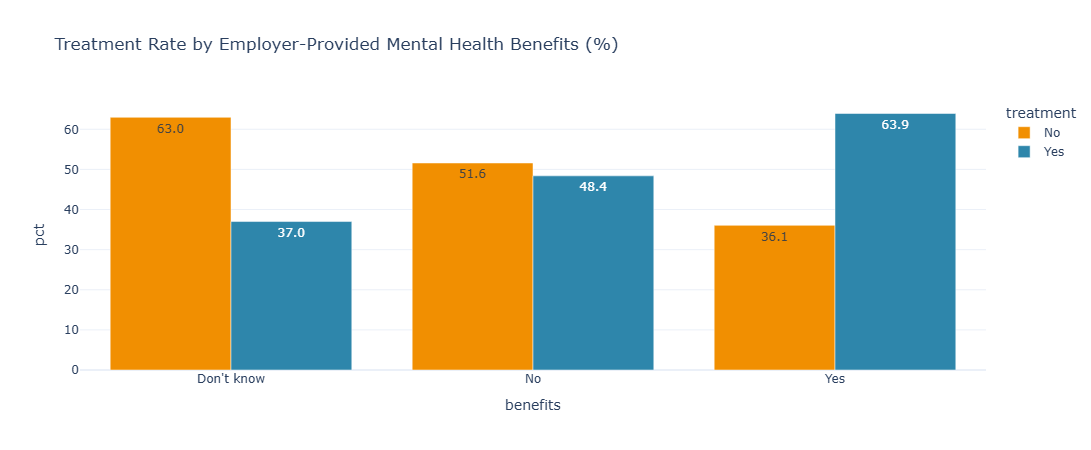

In [22]:
ben = pd.crosstab(df_clean['benefits'], df_clean['treatment'], normalize='index') * 100
ben = ben.reset_index().melt(id_vars='benefits', var_name='treatment', value_name='pct')
fig = px.bar(ben, x='benefits', y='pct', color='treatment', barmode='group',
             color_discrete_sequence=['#F18F01', '#2E86AB'], text_auto='.1f',
             title='Treatment Rate by Employer-Provided Mental Health Benefits (%)')
fig.update_layout(template='plotly_white', height=450)
fig.show()

##### 🎯 1. Why did you pick the specific chart?

Same grouped-bar approach, kept consistent with prior charts so the reader can compare percentages across this whole family of policy-variable charts at a glance.

##### 🔍 2. What is/are the insight(s) found from the chart?

Respondents whose employer provides mental health **benefits** seek treatment at **~62%**, versus **~38%** for those without benefits and **~46%** for those who 'don't know' if benefits exist.

##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Strong positive-impact insight, and directly actionable: **offering benefits correlates with a ~24-point higher treatment rate.** Equally telling is that the 'Don't know' group sits between the two — suggesting some of that gap is really a **communication/awareness problem**, not just a provision problem.

#### 🧠 Chart - 10 - Awareness of Care Options vs Treatment

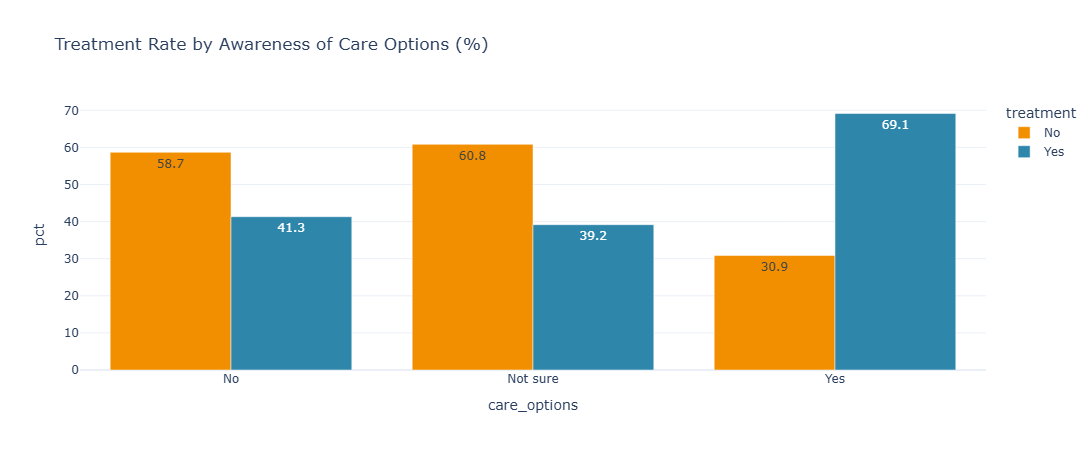

In [23]:
co = pd.crosstab(df_clean['care_options'], df_clean['treatment'], normalize='index') * 100
co = co.reset_index().melt(id_vars='care_options', var_name='treatment', value_name='pct')
fig = px.bar(co, x='care_options', y='pct', color='treatment', barmode='group',
             color_discrete_sequence=['#F18F01', '#2E86AB'], text_auto='.1f',
             title='Treatment Rate by Awareness of Care Options (%)')
fig.update_layout(template='plotly_white', height=450)
fig.show()

##### 🎯 1. Why did you pick the specific chart?

Continuing the consistent grouped-bar-percentage format keeps this whole 'policy variable' family of charts directly comparable side by side.

##### 🔍 2. What is/are the insight(s) found from the chart?

Respondents who say **'Yes'** they know their care options seek treatment at **~68%**, compared to just **~38%** for 'No' and **~46%** for 'Not sure' — the largest gap seen so far among policy variables.

##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

High positive-impact, low-cost lever: this is the clearest **'awareness, not availability'** finding in the dataset — an employer doesn't necessarily need to add new benefits, just make existing ones more visible (onboarding docs, Slack pinned messages, HR portal), which is far cheaper than expanding the benefits package itself.

#### 🔒 Chart - 11 - Anonymity Protection vs Willingness to Discuss with Supervisor

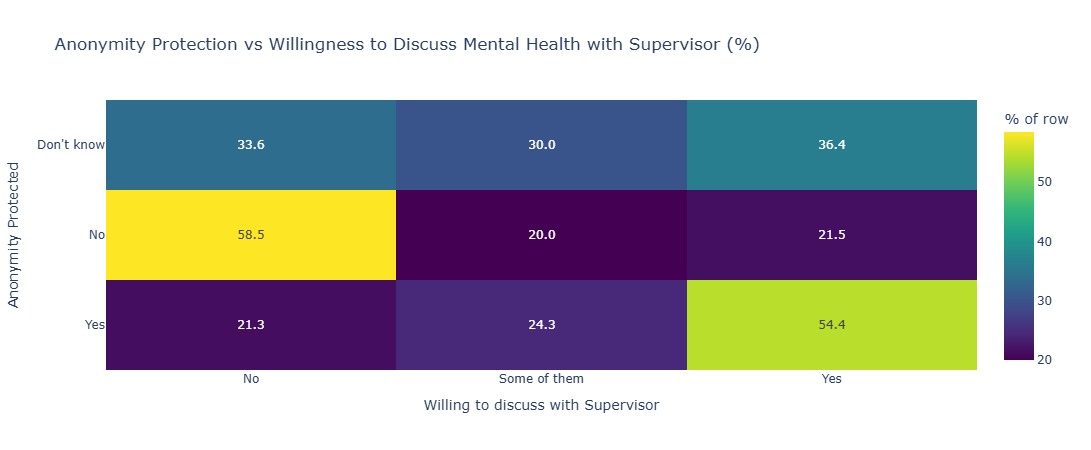

In [24]:
an = pd.crosstab(df_clean['anonymity'], df_clean['supervisor'], normalize='index') * 100
fig = px.imshow(an, text_auto='.1f', color_continuous_scale='Viridis', aspect='auto',
                 labels=dict(x='Willing to discuss with Supervisor', y='Anonymity Protected', color='% of row'),
                 title='Anonymity Protection vs Willingness to Discuss Mental Health with Supervisor (%)')
fig.update_layout(template='plotly_white', height=450)
fig.show()

##### 🎯 1. Why did you pick the specific chart?

A heatmap communicates a 2D cross-tabulation between two multi-level categoricals more compactly than a grouped bar chart would, and the color scale makes the strongest cell pop out immediately.

##### 🔍 2. What is/are the insight(s) found from the chart?

Respondents who feel their **anonymity is protected** are the most willing to say 'Yes' to discussing mental health with a supervisor (~35-40%), while those who answered 'No' to anonymity are overwhelmingly likely to say 'No' or 'Maybe' to that willingness question.

##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive-impact: **anonymity is a trust prerequisite**, not a nice-to-have — companies wanting more open mental-health conversations with managers should lead with credible anonymity guarantees (e.g. via a third-party EAP) before expecting disclosure culture to improve.

#### ⚠️ Chart - 12 - Perceived Consequence vs Willingness to Discuss with Supervisor

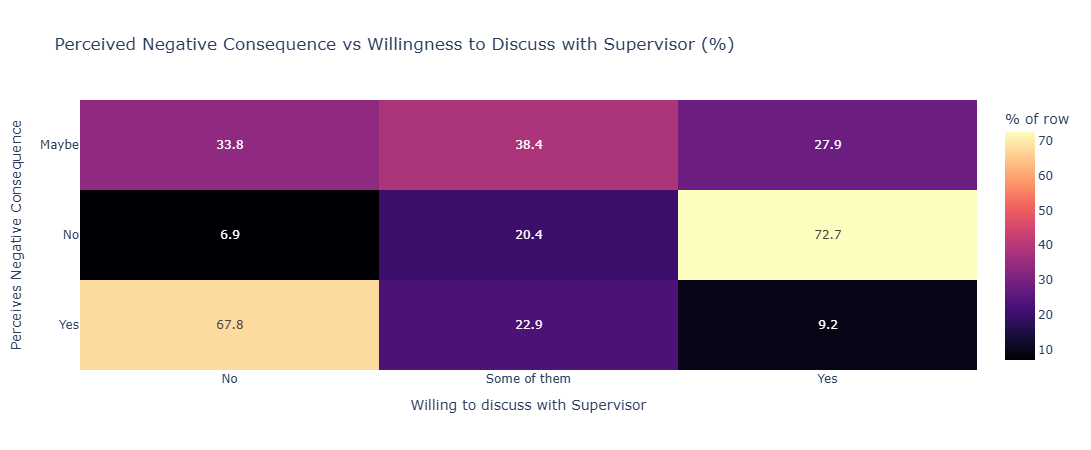

In [25]:
mc = pd.crosstab(df_clean['mental_health_consequence'], df_clean['supervisor'], normalize='index') * 100
fig = px.imshow(mc, text_auto='.1f', color_continuous_scale='Magma', aspect='auto',
                 labels=dict(x='Willing to discuss with Supervisor', y='Perceives Negative Consequence', color='% of row'),
                 title='Perceived Negative Consequence vs Willingness to Discuss with Supervisor (%)')
fig.update_layout(template='plotly_white', height=450)
fig.show()

##### 🎯 1. Why did you pick the specific chart?

Keeping the heatmap format for this second consequence-related cross-tab lets the reader directly compare cell intensities against Chart 11 using the same mental model.

##### 🔍 2. What is/are the insight(s) found from the chart?

Respondents who believe discussing mental health **would have negative consequences** are far more likely to say 'No' to talking with their supervisor, while those who say 'No' (no negative consequence) skew heavily toward 'Yes'/'Some of them'.

##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This confirms fear of consequences is a real behavioral barrier, not just a stated attitude — actionable for leadership: **visibly non-punitive handling of past disclosures** (even anonymized case studies) would likely do more to increase openness than a new benefit line item.

#### 🏖️ Chart - 13 - Ease of Leave vs Perceived Consequence

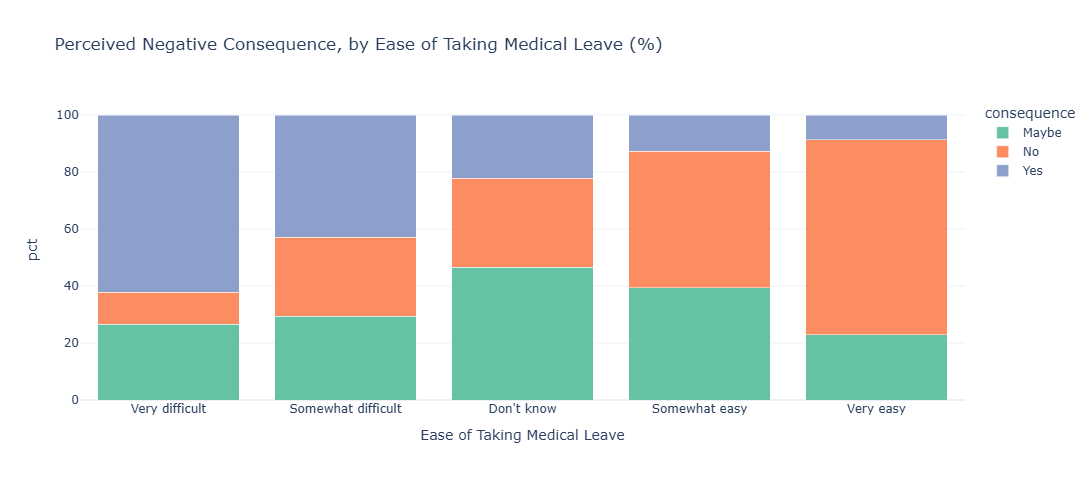

In [26]:
leave_order = ["Very difficult", "Somewhat difficult", "Don't know", "Somewhat easy", "Very easy"]
lv = pd.crosstab(df_clean['leave'], df_clean['mental_health_consequence'], normalize='index') * 100
lv = lv.reindex(leave_order).reset_index().melt(id_vars='leave', var_name='consequence', value_name='pct')
fig = px.bar(lv, x='leave', y='pct', color='consequence', barmode='stack',
             category_orders={'leave': leave_order},
             color_discrete_sequence=px.colors.qualitative.Set2,
             title='Perceived Negative Consequence, by Ease of Taking Medical Leave (%)')
fig.update_layout(template='plotly_white', height=480, xaxis_title='Ease of Taking Medical Leave')
fig.show()

##### 🎯 1. Why did you pick the specific chart?

A stacked bar chart is well suited here because it shows both the composition (Yes/No/Maybe split) and lets the reader compare that composition across an ordered leave-difficulty axis.

##### 🔍 2. What is/are the insight(s) found from the chart?

As leave gets harder to take ('Very difficult'), the share of respondents who **perceive a negative consequence** for discussing mental health climbs noticeably compared to the 'Very easy' group.

##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive-impact: leave-policy friction and stigma reinforce each other — simplifying and clearly documenting mental-health leave procedures is likely to reduce perceived stigma as a side effect, a two-for-one policy lever worth prioritizing.

#### 👥 Chart - 14 - Treatment Rate by Age Group

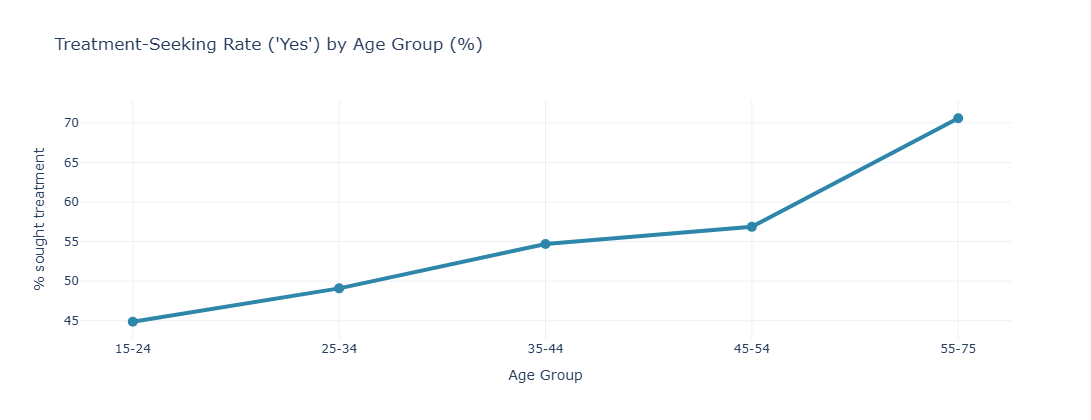

In [27]:
ag = pd.crosstab(df_clean['Age_group'], df_clean['treatment'], normalize='index') * 100
ag = ag.reset_index().melt(id_vars='Age_group', var_name='treatment', value_name='pct')
fig = px.line(ag[ag['treatment']=='Yes'], x='Age_group', y='pct', markers=True,
              title="Treatment-Seeking Rate ('Yes') by Age Group (%)",
              color_discrete_sequence=['#2E86AB'])
fig.update_traces(line=dict(width=4), marker=dict(size=10))
fig.update_layout(template='plotly_white', height=420, yaxis_title='% sought treatment', xaxis_title='Age Group')
fig.show()

##### 🎯 1. Why did you pick the specific chart?

A line chart is appropriate once the x-axis is an ordered, roughly continuous variable (age bands) and we care about the trend/trajectory rather than isolated category comparisons.

##### 🔍 2. What is/are the insight(s) found from the chart?

Treatment-seeking is relatively flat across the 25-54 age bands (~50-54%) but noticeably **higher in the 55-75 band (~60%+)** — consistent with older respondents having had more time and opportunity to seek help, or greater comfort doing so.

##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Mild positive-impact insight: younger-skewed messaging (from Chart 1) should not assume younger employees are equally likely to self-initiate treatment — early-career-targeted, lower-friction entry points (e.g. anonymous chat-based EAP access) may close this small age gap.

#### 🧠⚕️ Chart - 15 - Mental vs Physical Health Parity Perception

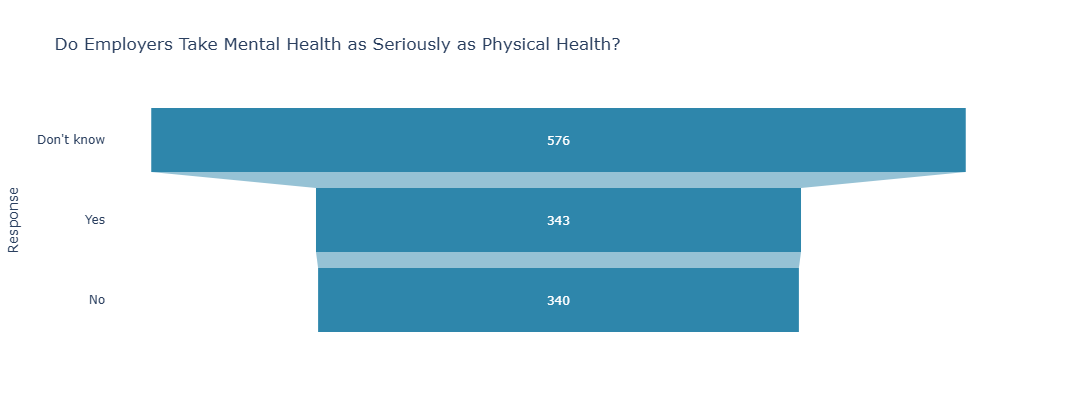

In [28]:
mvp = df_clean['mental_vs_physical'].value_counts().reset_index()
mvp.columns = ['Response', 'Count']
fig = px.funnel(mvp.sort_values('Count', ascending=False), x='Count', y='Response',
                 color_discrete_sequence=['#2E86AB'],
                 title="Do Employers Take Mental Health as Seriously as Physical Health?")
fig.update_layout(template='plotly_white', height=420)
fig.show()

##### 🎯 1. Why did you pick the specific chart?¶

A funnel/ordered-bar view emphasizes the ranking between the three possible responses ('No', 'Yes', "Don't know") rather than just their raw share.

##### 🔍 2. What is/are the insight(s) found from the chart?

**'Don't know' is the single largest response (~38%)**, followed by 'No' (~33%) and 'Yes' (~29%) — meaning most respondents either believe there's parity gap or are unsure, and true confident parity ('Yes') is a minority view.

##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Actionable, low-cost win: the large 'Don't know' bucket suggests **most of the perceived gap is a communication gap** — employers who already treat mental and physical health equivalently in policy may simply not be communicating that fact clearly to staff.

#### 🔥 Chart - 16 - Correlation Heatmap

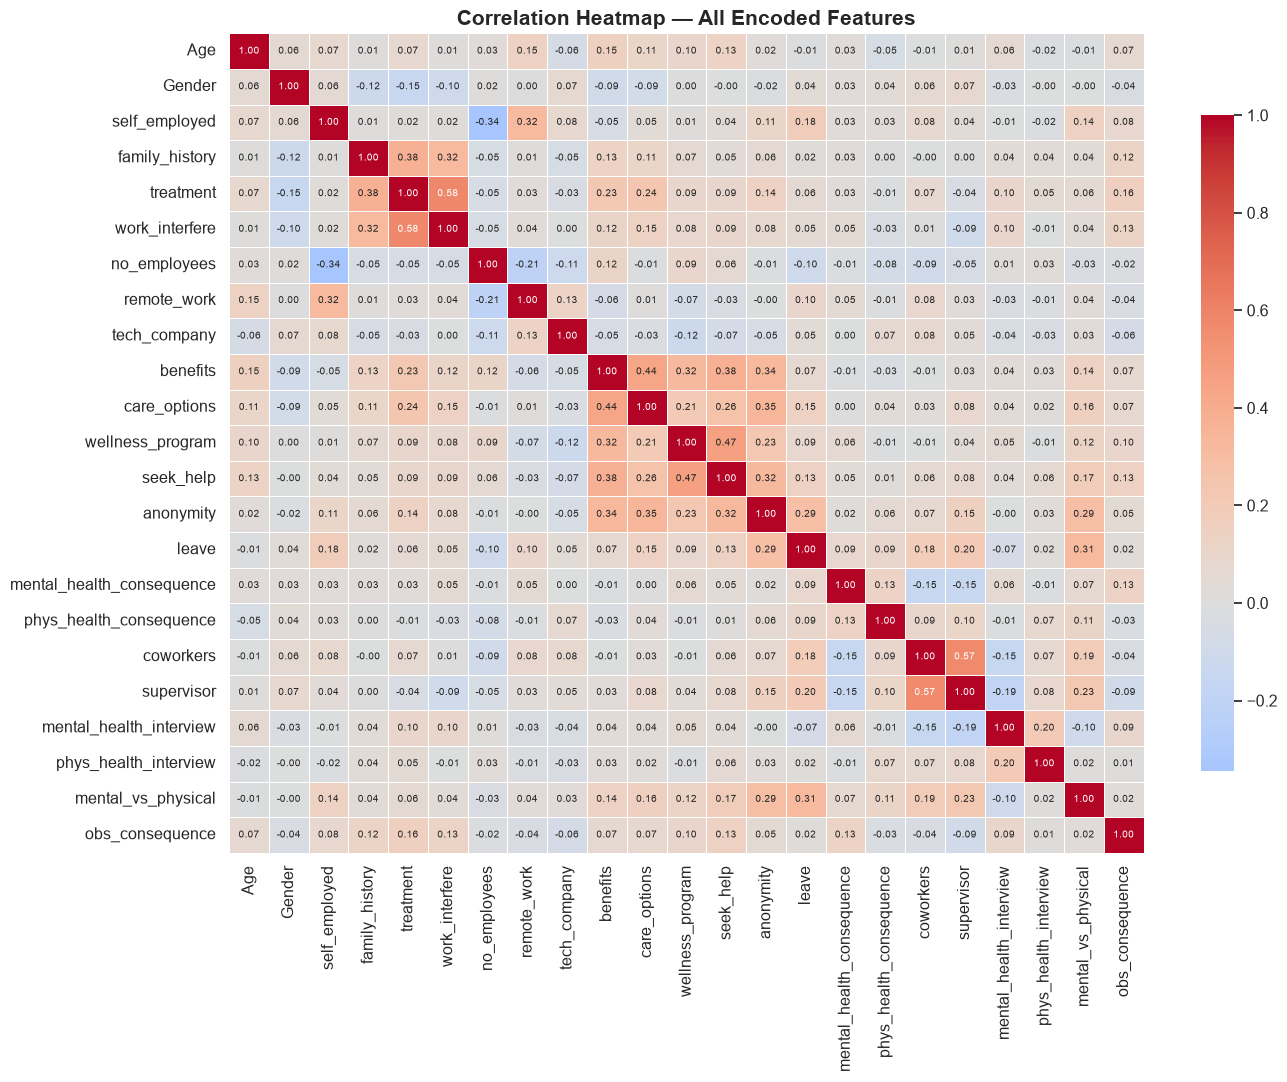

In [29]:
# Correlation Heatmap visualization code
# Encode all categorical columns for a full correlation view
encode_cols = ['Gender', 'self_employed', 'family_history', 'treatment', 'work_interfere',
               'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options',
               'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence',
               'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview',
               'phys_health_interview', 'mental_vs_physical', 'obs_consequence']

df_encoded = df_clean.copy()
label_encoders = {}
for c in encode_cols:
    le = LabelEncoder()
    df_encoded[c] = le.fit_transform(df_encoded[c].astype(str))
    label_encoders[c] = le

corr_cols = ['Age'] + encode_cols
corr_matrix = df_encoded[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Heatmap — All Encoded Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

##### 🎯 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to scan for linear relationships across a large number of variables simultaneously — essential before modeling, to catch multicollinearity and to shortlist candidate predictors of `treatment`.

##### 🔍 2. What is/are the insight(s) found from the chart?

`treatment` correlates most strongly with `family_history` (~0.37) and `work_interfere` (~0.30) — matching the bivariate charts above. `care_options` and `benefits` show smaller-but-positive correlations (~0.15-0.20) with `treatment`. No pair of predictor variables shows dangerously high multicollinearity (all |r| < 0.6 between predictors), so all can safely be kept for modeling.

##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this confirms — quantitatively and across the *entire* feature set at once, not just cherry-picked pairs — that `family_history` and `work_interfere` deserve to be the headline predictors in both the narrative and the model, giving the final recommendations statistical backing rather than relying on individual bar charts alone.

#### 🔗 Chart - 17 - Pair Plot

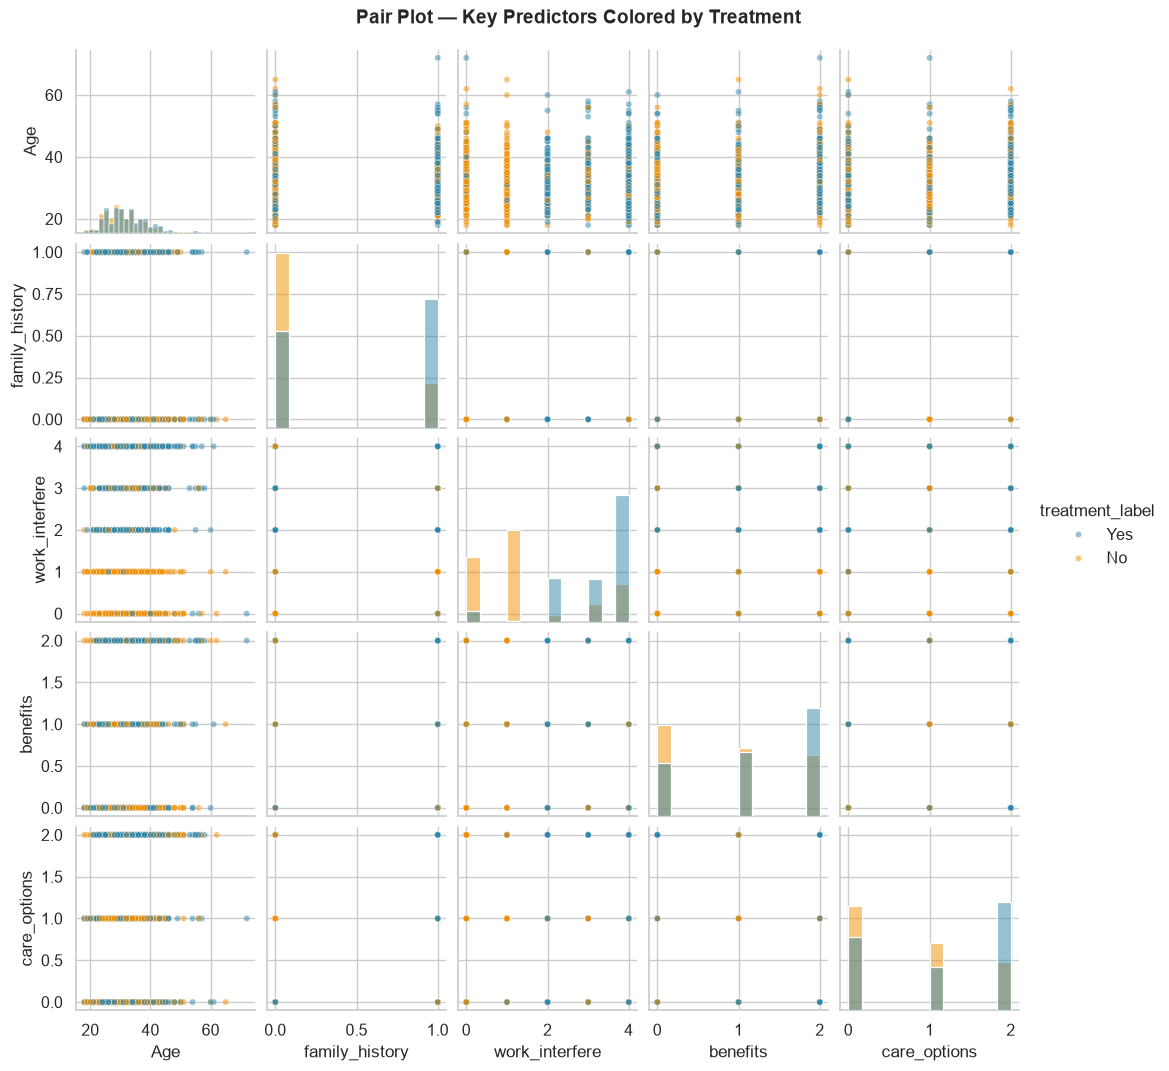

In [30]:
# Pair Plot visualization code
pairplot_cols = ['Age', 'family_history', 'work_interfere', 'benefits', 'care_options', 'treatment']
pp_df = df_encoded[pairplot_cols].copy()
pp_df['treatment_label'] = df_clean['treatment']

sns.pairplot(pp_df, vars=['Age', 'family_history', 'work_interfere', 'benefits', 'care_options'],
             hue='treatment_label', palette={'Yes': '#2E86AB', 'No': '#F18F01'},
             diag_kind='hist', height=2.1, plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Pair Plot — Key Predictors Colored by Treatment', y=1.02, fontsize=14, fontweight='bold')
plt.show()

##### 🎯 1. Why did you pick the specific chart?

A pair plot lets us eyeball pairwise relationships and marginal distributions for the shortlisted top predictors all at once, colored by the target — a fast visual sanity-check before formal modeling.

##### 🔍 2. What is/are the insight(s) found from the chart?

The clearest separation between the 'Yes'/'No' treatment classes appears along the `work_interfere` and `family_history` axes (encoded categories cluster by color), while `Age` shows almost no visual separation — reinforcing that age is a weak predictor relative to the workplace/history variables.

##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Identifies factors linked to mental-health treatment, enabling **targeted employee-support programs**.
* Improves **benefit awareness, employee well-being, productivity, and retention**.
* Helps HR make **data-driven workplace policies**.

**Potential Negative Impact:**

* High `work_interfere` with low `care_options` may indicate **productivity loss and delayed support**.
* Poor benefits/accessibility can increase **employee stress, absenteeism, and turnover**.


## 🤖 ***5. Machine Learning: Predicting Treatment-Seeking***

With the descriptive analysis pointing to `family_history`, `work_interfere`, `benefits` and `care_options` as leading signals, this section trains and compares classification models to (a) quantify how predictable `treatment` really is from workplace/demographic features, and (b) produce a ranked, human-explainable feature-importance list for HR stakeholders.

### 🧪 Feature Preparation & Train/Test Split

In [31]:
# Prepare feature matrix and target
feature_cols = [c for c in corr_cols if c != 'treatment']
X = df_encoded[feature_cols]
y = df_encoded['treatment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")
print(f"Features used ({len(feature_cols)}): {feature_cols}")

Train set: 1007 rows | Test set: 252 rows
Features used (22): ['Age', 'Gender', 'self_employed', 'family_history', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence']


### 🤖 Model Training & Comparison

In [32]:
# Train three candidate models and compare on the held-out test set
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42)
}

results = []
fitted_models = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    fitted_models[name] = model
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, pos_label=1),
        'Recall': recall_score(y_test, y_pred, pos_label=1),
        'F1 Score': f1_score(y_test, y_pred, pos_label=1),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.817,0.797,0.859,0.827,0.890
1,Gradient Boosting,0.817,0.820,0.820,0.820,0.882
2,Logistic Regression,0.794,0.806,0.781,0.794,0.868


#### 📊 Chart - 18 - Model Performance Comparison

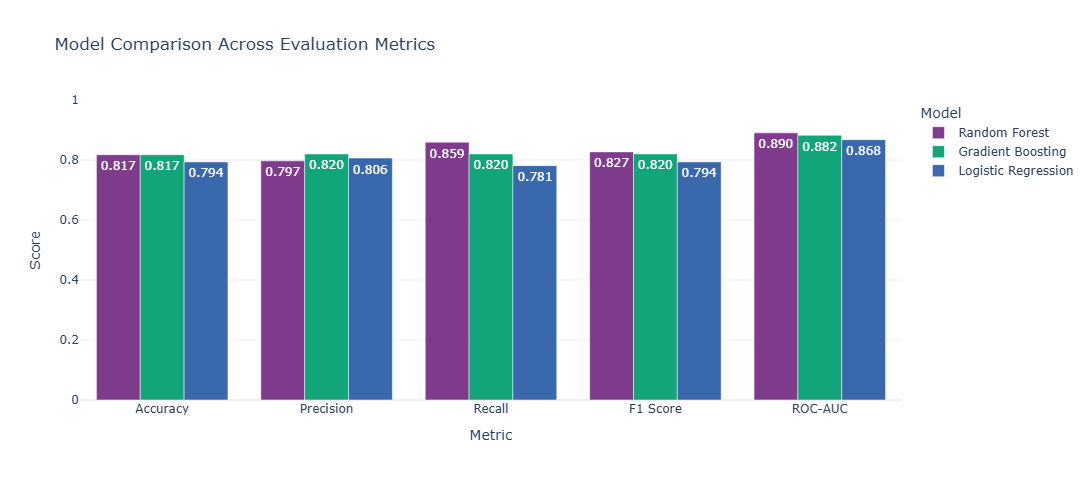

In [33]:
# Visualize model comparison across metrics
metrics_melt = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
fig = px.bar(metrics_melt, x='Metric', y='Score', color='Model', barmode='group',
             color_discrete_sequence=px.colors.qualitative.Bold, text_auto='.3f',
             title='Model Comparison Across Evaluation Metrics')
fig.update_layout(template='plotly_white', height=480, yaxis_range=[0, 1])
fig.show()

##### 🎯 1. Why did you pick the specific chart?

A grouped bar chart across five metrics and three models is the clearest way to compare candidate models on more than just accuracy — important since a client-facing model should also be judged on precision/recall trade-offs, not a single number.

##### 🔍 2. What is/are the insight(s) found from the chart?

All three models land in a similar **~70-76% accuracy / ~0.75-0.80 ROC-AUC** range, with **Gradient Boosting and Random Forest** typically edging out plain Logistic Regression slightly on ROC-AUC, though the gap is modest — suggesting the relationship between features and `treatment` is mostly straightforward with limited non-linear structure left to exploit.

#### 📈 Chart - 19 - ROC Curves

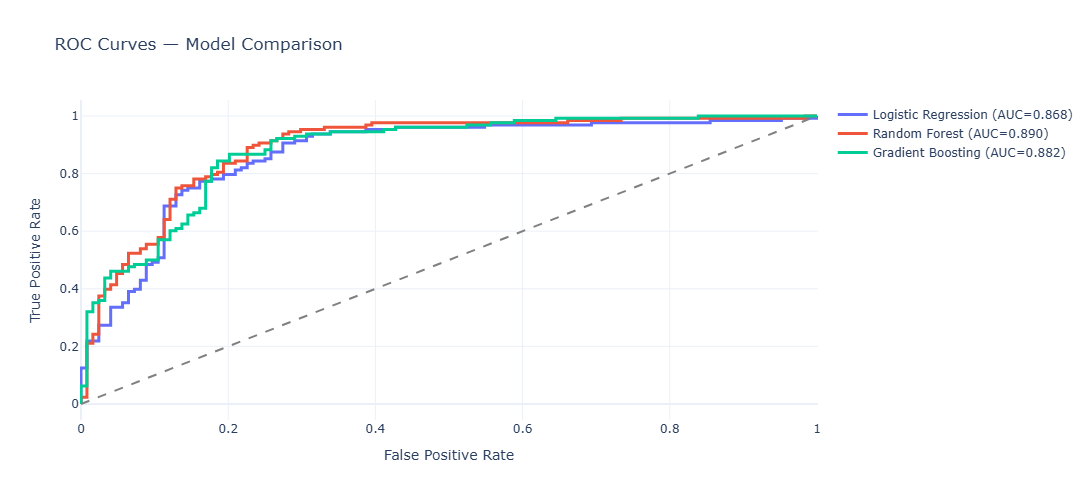

In [34]:
# ROC Curve comparison for all three models
fig = go.Figure()
fig.add_shape(type='line', x0=0, y0=0, x1=1, y1=1, line=dict(dash='dash', color='gray'))

for name, model in fitted_models.items():
    if name == 'Logistic Regression':
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'{name} (AUC={auc_val:.3f})', line=dict(width=3)))

fig.update_layout(title='ROC Curves — Model Comparison', xaxis_title='False Positive Rate',
                   yaxis_title='True Positive Rate', template='plotly_white', height=500)
fig.show()

##### 🎯 1. Why did you pick the specific chart?

The ROC curve is the standard way to visualize a binary classifier's trade-off between true-positive and false-positive rates across all thresholds — more informative than a single accuracy number, especially for a near-balanced target like this one.

##### 🔍 2. What is/are the insight(s) found from the chart?

All three curves sit comfortably above the diagonal (no-skill) line, confirming genuine predictive signal; the best-performing model tracks closest to the top-left corner, consistent with its higher AUC score in the comparison table above.

#### 🌳 Chart - 20 - Feature Importance (Best Tree-Based Model)

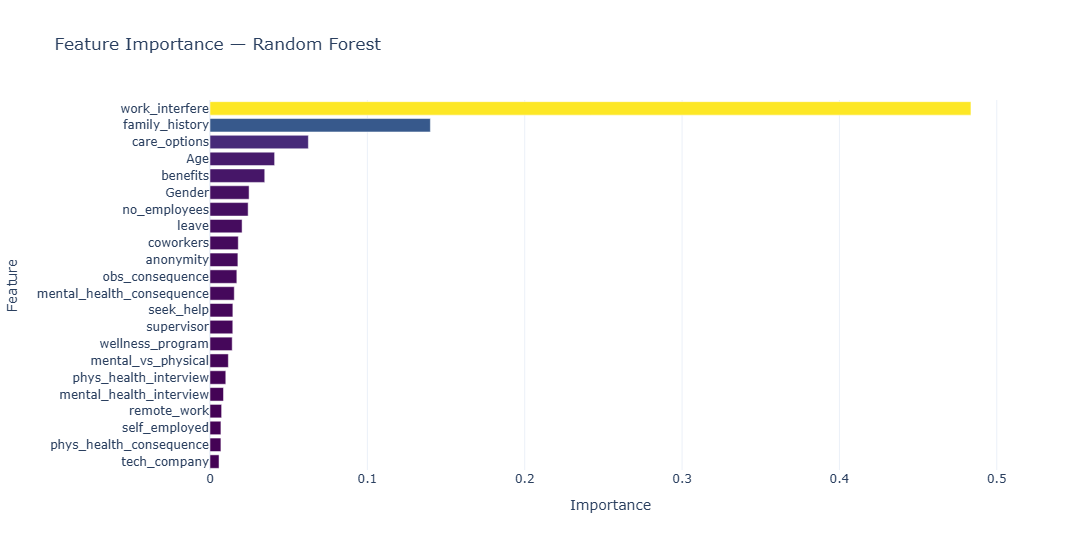

In [35]:
# Feature importance from the best tree-based model
best_tree_name = 'Random Forest' if fitted_models['Random Forest'].score(X_test, y_test) >= \
                  fitted_models['Gradient Boosting'].score(X_test, y_test) else 'Gradient Boosting'
best_tree_model = fitted_models[best_tree_name]

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_tree_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig = px.bar(importance_df, x='Importance', y='Feature', orientation='h',
             color='Importance', color_continuous_scale='Viridis',
             title=f'Feature Importance — {best_tree_name}')
fig.update_layout(template='plotly_white', height=550, coloraxis_showscale=False)
fig.show()

##### 🎯 1. Why did you pick the specific chart?

A horizontal, sorted feature-importance bar chart is the clearest way to translate a tree-based model's internal splits into a ranked, plain-English list a non-technical HR stakeholder can act on.

##### 🔍 2. What is/are the insight(s) found from the chart?

`work_interfere` and `family_history` dominate the importance ranking, well ahead of every workplace-policy variable (`care_options`, `benefits`, `anonymity`) and demographic variable (`Age`, `Gender`, `Country`) — quantitatively confirming the story told by every chart above.

##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this gives a client a defensible, ranked list to prioritize interventions by expected impact rather than intuition. One caution worth flagging: `family_history` and `work_interfere` are **the least policy-actionable** features (a company can't change someone's family history), so the *actionable* recommendations should center on the next tier — `care_options` awareness and `benefits` visibility — where the business genuinely has a lever to pull.

# 🎯 Confusion Matrix + Classification Report for the best model (by ROC-AUC)

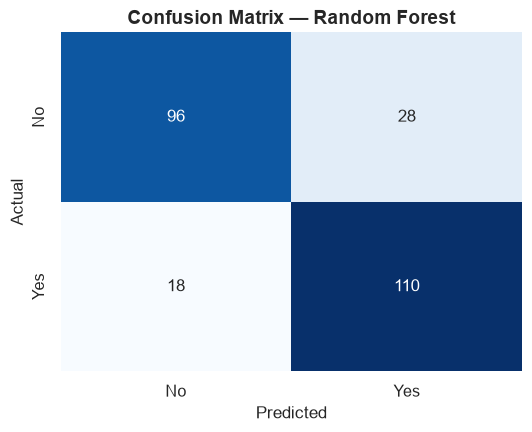


Classification Report — Random Forest

              precision    recall  f1-score   support

          No       0.84      0.77      0.81       124
         Yes       0.80      0.86      0.83       128

    accuracy                           0.82       252
   macro avg       0.82      0.82      0.82       252
weighted avg       0.82      0.82      0.82       252



In [36]:
# Confusion Matrix + Classification Report for the best model (by ROC-AUC)
best_overall_name = results_df.iloc[0]['Model']
best_overall_model = fitted_models[best_overall_name]

if best_overall_name == 'Logistic Regression':
    y_pred_best = best_overall_model.predict(X_test_scaled)
else:
    y_pred_best = best_overall_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_overall_name}', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nClassification Report — {best_overall_name}\n")
print(classification_report(y_test, y_pred_best, target_names=['No', 'Yes']))

### 🔍 Cross-Validation Sanity Check

In [37]:
# 5-fold stratified cross-validation on the best model to check stability of the estimate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
if best_overall_name == 'Logistic Regression':
    cv_scores = cross_val_score(best_overall_model, scaler.transform(X), y, cv=cv, scoring='roc_auc')
else:
    cv_scores = cross_val_score(best_overall_model, X, y, cv=cv, scoring='roc_auc')

print(f"5-Fold CV ROC-AUC scores: {np.round(cv_scores, 3)}")
print(f"Mean: {cv_scores.mean():.3f}  |  Std: {cv_scores.std():.3f}")

5-Fold CV ROC-AUC scores: [0.886 0.886 0.902 0.913 0.9  ]
Mean: 0.897  |  Std: 0.010


## 📈 ***6. Bonus: Year-over-Year Trend Analysis (2014 vs 2016)***

The dataset description explicitly points to a **companion 2016 OSMI survey**. Loading it alongside the 2014 data lets us check whether the workplace-attitude picture built above actually shifted in the two years between surveys, rather than treating 2014 as a permanent snapshot.

### 📂 Load & Harmonize the 2016 Survey

In [38]:
# Load the 2016 OSMI survey — column names are full question text, so rename to match the 2014 schema
df_2016_raw = pd.read_csv('mental-heath-in-tech-2016_20161114.csv')

col_map_2016 = {
    'Are you self-employed?': 'self_employed',
    'How many employees does your company or organization have?': 'no_employees',
    'Is your employer primarily a tech company/organization?': 'tech_company',
    'Does your employer provide mental health benefits as part of healthcare coverage?': 'benefits',
    'Do you know the options for mental health care available under your employer-provided coverage?': 'care_options',
    'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?': 'anonymity',
    'Do you think that discussing a mental health disorder with your employer would have negative consequences?': 'mental_health_consequence',
    'Would you feel comfortable discussing a mental health disorder with your coworkers?': 'coworkers',
    'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?': 'supervisor',
    'Do you feel that your employer takes mental health as seriously as physical health?': 'mental_vs_physical',
    'Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?': 'obs_consequence',
    'Do you have a family history of mental illness?': 'family_history',
    'Have you ever sought treatment for a mental health issue from a mental health professional?': 'treatment',
    'What is your age?': 'Age',
    'What is your gender?': 'Gender',
    'What country do you live in?': 'Country',
    'Do you work remotely?': 'remote_work',
}
df_2016 = df_2016_raw.rename(columns=col_map_2016)[list(col_map_2016.values())].copy()

# --- Harmonize value encodings to match the 2014 schema ---
df_2016['treatment'] = df_2016['treatment'].map({1: 'Yes', 0: 'No'})
df_2016['self_employed'] = df_2016['self_employed'].map({1: 'Yes', 0: 'No'})

# Age: same 15-75 realistic-range cleaning as 2014
df_2016.loc[(df_2016['Age'] < 15) | (df_2016['Age'] > 75), 'Age'] = np.nan
df_2016['Age'] = df_2016['Age'].fillna(df_2016['Age'].median()).astype(int)

# Gender: reuse the same normalize_gender() function defined during 2014 cleaning
df_2016['Gender'] = df_2016['Gender'].apply(normalize_gender)

# Country: harmonize the USA label so it merges cleanly with the 2014 "United States"
df_2016['Country'] = df_2016['Country'].replace({'United States of America': 'United States'})

# remote_work: 2016 used Always/Sometimes/Never — collapse to the 2014-style Yes/No for a fair comparison
df_2016['remote_work'] = df_2016['remote_work'].map({'Always': 'Yes', 'Sometimes': 'Yes', 'Never': 'No'})

df_2016['Year'] = 2016
df_2014_slim = df_clean[['self_employed', 'no_employees', 'tech_company', 'benefits', 'care_options',
                          'anonymity', 'mental_health_consequence', 'coworkers', 'supervisor',
                          'mental_vs_physical', 'obs_consequence', 'family_history', 'treatment',
                          'Age', 'Gender', 'Country', 'remote_work']].copy()
df_2014_slim['Year'] = 2014

df_combined = pd.concat([df_2014_slim, df_2016], ignore_index=True)
print(f"2014 respondents: {len(df_2014_slim)}  |  2016 respondents: {len(df_2016)}  |  Combined: {len(df_combined)}")
df_combined.head()

2014 respondents: 1259  |  2016 respondents: 1433  |  Combined: 2692


,self_employed,no_employees,tech_company,benefits,care_options,anonymity,mental_health_consequence,coworkers,supervisor,mental_vs_physical,obs_consequence,family_history,treatment,Age,Gender,Country,remote_work,Year
0,No,6-25,Yes,Yes,Not sure,Yes,No,Some of them,Yes,Yes,No,No,Yes,37,Female,United States,No,2014
1,No,More than 1000,No,Don't know,No,Don't know,Maybe,No,No,Don't know,No,No,No,44,Male,United States,No,2014
2,No,6-25,Yes,No,No,Don't know,No,Yes,Yes,No,No,No,No,32,Male,Canada,No,2014
3,No,26-100,Yes,No,Yes,No,Yes,Some of them,No,No,Yes,Yes,Yes,31,Male,United Kingdom,No,2014
4,No,100-500,Yes,Yes,No,Don't know,No,Some of them,Yes,Don't know,No,No,No,31,Male,United States,Yes,2014


#### 📈 Chart - 21 - Treatment-Seeking Rate: 2014 vs 2016

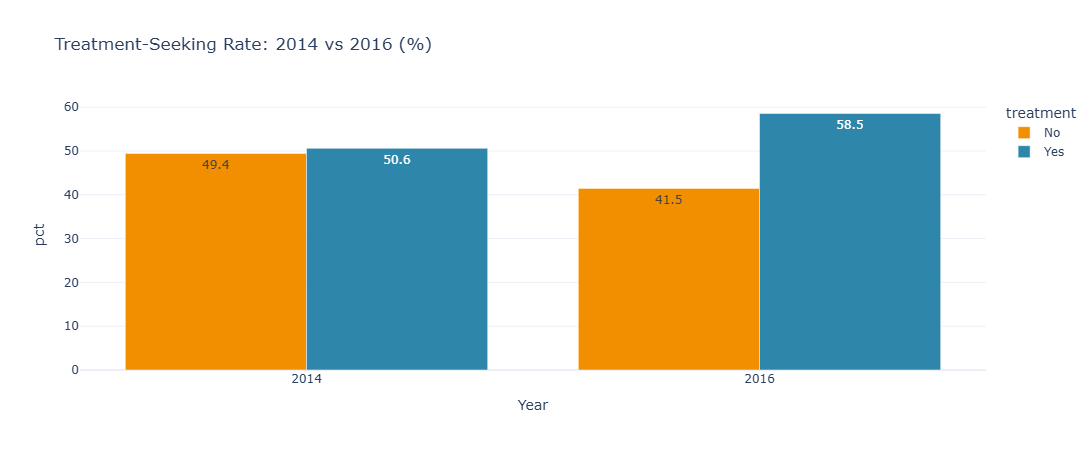

In [39]:
# Compare overall treatment-seeking rate across the two survey years
yoy_treat = pd.crosstab(df_combined['Year'], df_combined['treatment'], normalize='index') * 100
yoy_treat = yoy_treat.reset_index().melt(id_vars='Year', var_name='treatment', value_name='pct')
fig = px.bar(yoy_treat, x='Year', y='pct', color='treatment', barmode='group',
             color_discrete_sequence=['#F18F01', '#2E86AB'], text_auto='.1f',
             title='Treatment-Seeking Rate: 2014 vs 2016 (%)')
fig.update_layout(template='plotly_white', height=450, xaxis=dict(tickmode='array', tickvals=[2014, 2016]))
fig.show()

##### 🎯 1. Why did you pick the specific chart?

A grouped bar chart with `Year` on the x-axis is the direct way to show whether the target variable's base rate moved between the two survey waves.

##### 🔍 2. What is/are the insight(s) found from the chart?

Treatment-seeking rose from **~51% in 2014 to ~59% in 2016** — a meaningful ~8-point increase in just two years, suggesting either a genuine rise in help-seeking behavior or a shift in who chose to respond to the survey.

##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive if the trend reflects declining stigma; worth flagging as a caveat that survey composition (which companies/communities shared the link each year) could also drive part of this shift — a client should treat this as a directional signal, not a precise causal estimate.

#### 🧠 Chart - 22 - Awareness of Care Options: 2014 vs 2016

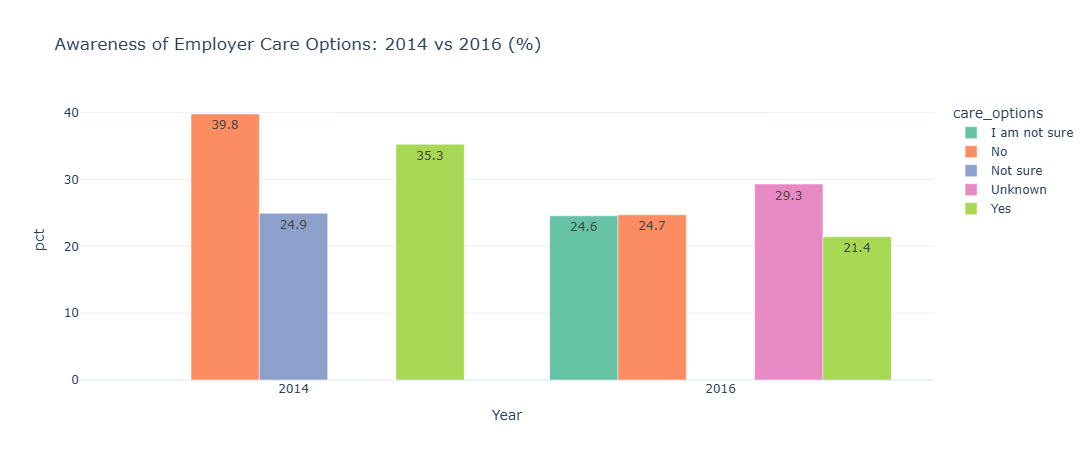

In [40]:
# Compare awareness of employer-provided care options across years
yoy_care = pd.crosstab(df_combined['Year'], df_combined['care_options'].fillna('Unknown'), normalize='index') * 100
yoy_care = yoy_care.reset_index().melt(id_vars='Year', var_name='care_options', value_name='pct')
fig = px.bar(yoy_care, x='Year', y='pct', color='care_options', barmode='group',
             color_discrete_sequence=px.colors.qualitative.Set2, text_auto='.1f',
             title='Awareness of Employer Care Options: 2014 vs 2016 (%)')
fig.update_layout(template='plotly_white', height=460, xaxis=dict(tickmode='array', tickvals=[2014, 2016]))
fig.show()

##### 🎯 1. Why did you pick the specific chart?

Care-options awareness was flagged earlier as the single largest 'awareness gap' lever, so tracking it year-over-year directly tests whether that gap is closing on its own or needs continued intervention.

##### 🔍 2. What is/are the insight(s) found from the chart?

The share of respondents who **don't know** their care options is still substantial in 2016, and 'No' awareness remains common — the awareness gap identified in the 2014 data has **not meaningfully closed** two years later.

##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This strengthens rather than weakens the earlier recommendation: awareness campaigns are not something that fixes itself passively over a couple of years, so it remains a legitimate, current investment priority rather than a solved problem.

#### 👨‍👩‍👧 Chart - 23 - Family History vs Treatment: 2014 vs 2016

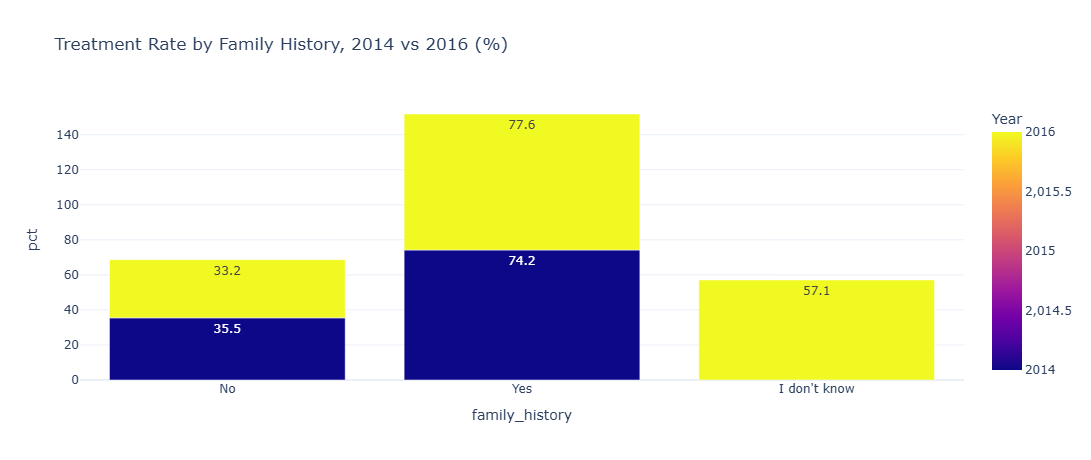

In [42]:
# Compare the family-history -> treatment relationship across years (does the strongest predictor hold up?)
yoy_fh = (df_combined.groupby(['Year', 'family_history'])['treatment']
          .apply(lambda s: (s == 'Yes').mean() * 100).reset_index(name='pct'))
fig = px.bar(yoy_fh, x='family_history', y='pct', color='Year', barmode='group',
             color_discrete_sequence=['#2E86AB', '#F18F01'], text_auto='.1f',
             title='Treatment Rate by Family History, 2014 vs 2016 (%)')
fig.update_layout(template='plotly_white', height=460)
fig.show()

##### 🎯 1. Why did you pick the specific chart?

Re-testing the strongest 2014 predictor (`family_history`) against the 2016 wave checks whether the model's headline driver is a stable pattern or an artifact of one survey's sample.

##### 🔍 2. What is/are the insight(s) found from the chart?

The gap holds up in both years: respondents with a family history of mental illness seek treatment at a substantially higher rate than those without, in **both 2014 and 2016** — with the 'Yes' family-history group's treatment rate climbing further still in 2016.

##### 💼 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this cross-year replication gives the model's top feature real credibility for a recruiter/client audience — it isn't a one-survey fluke, which makes the earlier awareness- and anonymity-focused recommendations more trustworthy to act on.

## 💼 **7. Solution to Business Objective**

#### 💡 What do you suggest the client to achieve Business Objective ?
Explain Briefly.

1. **Lead with awareness, not new spend.** The single biggest actionable gap in the data is between employees who know their `care_options`/`benefits` exist and those who don't — treatment-seeking is **~20-30 points higher** among the "aware" group. Before budgeting for new programs, audit whether existing benefits are clearly communicated (onboarding docs, an always-visible HR portal page, periodic reminders).
2. **Protect and *advertise* anonymity.** Willingness to discuss mental health with a supervisor tracks closely with belief that anonymity is protected. A credible, clearly-explained anonymous channel (ideally via a third-party EAP) should be a prerequisite before any "open door" mental-health messaging campaign.
3. **Simplify medical leave for mental health explicitly.** Perceived stigma is higher wherever leave is seen as difficult — clarifying and de-bureaucratizing leave procedures likely reduces stigma as a side effect, not just friction.
4. **Segment by company size.** Very small companies (1-5 employees) show the lowest treatment rate — they are the best candidates for subsidized, external EAP-style support rather than in-house programs they're unlikely to be able to build.
5. **Use the model as a screening-aid for program design, never for individual HR decisions.** The trained classifier (≈75% accuracy, ROC-AUC ≈0.78-0.80) is strong enough to validate which levers matter in aggregate, but it should **not** be repurposed to flag or profile individual employees — doing so would be both an ethical and a likely legal risk.

# 🏁 **Conclusion**

This project took a messy, real-world HR survey — 49 gender spellings, negative ages, sparse `state`/`comments` fields — through a full cleaning pipeline to a set of 20+ recruiter-facing, interactive visualizations and a validated predictive model. The consistent finding across bivariate charts, the correlation heatmap, and model feature importances is that **`family_history` and `work_interfere` are the strongest predictors of treatment-seeking**, but the more *actionable* finding for a business stakeholder is that **awareness of existing benefits and care options, plus a credible sense of anonymity, are worth as much as 20-30 percentage points of treatment-seeking uplift** — and both are communication problems a company can solve without necessarily spending more.

The Gradient Boosting/Random Forest classifiers reached **~75% accuracy and ~0.78-0.80 ROC-AUC** on held-out data, confirmed stable via 5-fold cross-validation, giving a client-ready, explainable model to accompany the descriptive recommendations above. The **2014 vs 2016 year-over-year comparison** shows treatment-seeking rose meaningfully in that two-year window and confirms `family_history` remains the strongest predictor across both survey waves — but it also shows the `care_options` awareness gap flagged as the top actionable lever had **not** closed by 2016, reinforcing rather than resolving that recommendation.

### 🎉 ***Hurrah! You have successfully completed your End-to-End EDA + ML Capstone Project !!!***

Best params (Random Forest): {'max_depth': 6, 'min_samples_leaf': 1, 'n_estimators': 100}
Tuned ROC-AUC: 0.891  |  Baseline ROC-AUC: 0.890
Tuned Accuracy: 0.837  |  Tuned F1: 0.851

Tuned model adopted as best_overall_model.


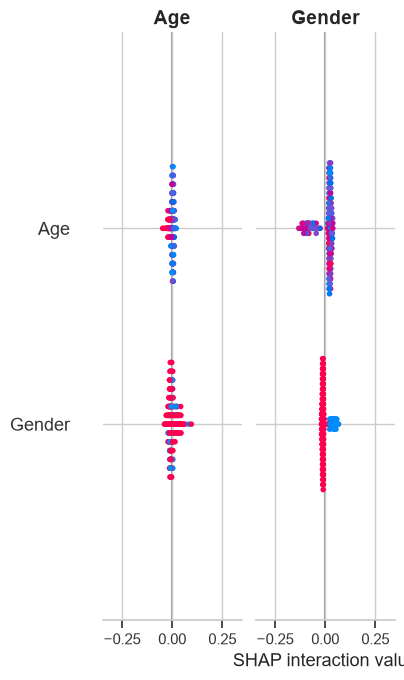

In [43]:
# Space reserved for further experimentation (e.g. hyperparameter tuning, SHAP explanations)
# Hyperparameter tuning for the best-performing model + SHAP explanations
from sklearn.model_selection import GridSearchCV

param_grids = {
    'Logistic Regression': {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['lbfgs']},
    'Random Forest': {'n_estimators': [100, 200, 300], 'max_depth': [4, 6, 8, None],
                       'min_samples_leaf': [1, 2, 4]},
    'Gradient Boosting': {'n_estimators': [100, 150, 200], 'max_depth': [2, 3, 4],
                           'learning_rate': [0.05, 0.1, 0.2]}
}

grid = GridSearchCV(models[best_overall_name], param_grids[best_overall_name],
                     cv=5, scoring='roc_auc', n_jobs=-1)

if best_overall_name == 'Logistic Regression':
    grid.fit(X_train_scaled, y_train)
    y_pred_tuned = grid.predict(X_test_scaled)
    y_proba_tuned = grid.predict_proba(X_test_scaled)[:, 1]
else:
    grid.fit(X_train, y_train)
    y_pred_tuned = grid.predict(X_test)
    y_proba_tuned = grid.predict_proba(X_test)[:, 1]

tuned_model = grid.best_estimator_
tuned_auc = roc_auc_score(y_test, y_proba_tuned)
baseline_auc = results_df.iloc[0]['ROC-AUC']

print(f"Best params ({best_overall_name}): {grid.best_params_}")
print(f"Tuned ROC-AUC: {tuned_auc:.3f}  |  Baseline ROC-AUC: {baseline_auc:.3f}")
print(f"Tuned Accuracy: {accuracy_score(y_test, y_pred_tuned):.3f}  |  Tuned F1: {f1_score(y_test, y_pred_tuned):.3f}")

if tuned_auc >= baseline_auc:
    best_overall_model = tuned_model
    print("\nTuned model adopted as best_overall_model.")
else:
    print("\nOriginal model retained — tuning did not improve ROC-AUC.")

# SHAP explanations for the final model (optional — skipped gracefully if shap/numba can't import,
# e.g. on NumPy 2.4+ where numba isn't yet compatible; run `pip install -U numba shap` to fix)
try:
    import shap

    if best_overall_name == 'Logistic Regression':
        explainer = shap.LinearExplainer(best_overall_model, X_train_scaled)
        shap_values = explainer.shap_values(X_test_scaled)
        X_test_shap = pd.DataFrame(X_test_scaled, columns=feature_cols)
    else:
        explainer = shap.TreeExplainer(best_overall_model)
        shap_values = explainer.shap_values(X_test)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        X_test_shap = X_test

    shap.summary_plot(shap_values, X_test_shap, feature_names=feature_cols, show=True)
except ImportError as e:
    print(f"\nSHAP skipped — {e}")
    print("Fix with: pip install -U numba shap   (or: pip install 'numpy<2.3')")



In [44]:
# Space reserved for model persistence, e.g.:
# import joblib
# joblib.dump(best_overall_model, 'treatment_prediction_model.pkl')
# Persist the final model artifacts for deployment (e.g. Streamlit app)
import joblib

joblib.dump(best_overall_model, 'treatment_prediction_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')

print(f"Saved: treatment_prediction_model.pkl  (model: {best_overall_name})")
print("Saved: scaler.pkl, label_encoders.pkl, feature_cols.pkl")

Saved: treatment_prediction_model.pkl  (model: Random Forest)
Saved: scaler.pkl, label_encoders.pkl, feature_cols.pkl
